In [6]:
import os
import numpy as np
import librosa

folder_path = r"C:\Users\amiru\OneDrive\Desktop\AlFatihah_HF_Audio_AUG"

verse_keyword_map = {
    "بِسْمِ اللَّهِ الرَّحْمَنِ الرَّحِيمِ": 1,
    "الْحَمْدُ لِلَّهِ رَبِّ الْعَالَمِينَ": 2,
    "الرَّحْمَنِ الرَّحِيمِ": 3,
    "مَالِكِ يَوْمِ الدِّينِ": 4,
    "إِيَّاكَ نَعْبُدُ وَإِيَّاكَ نَسْتَعِينُ": 5,
    "اهْدِنَا الصِّرَاطَ الْمُسْتَقِيمَ": 6,
    "صِرَاطَ الَّذِينَ أَنْعَمْتَ عَلَيْهِمْ غَيْرِ الْمَغْضُوبِ عَلَيْهِمْ وَلَا الضَّالِّينَ": 7
}

n_mels = 60
max_len = 180

X, y = [], []

for file in os.listdir(folder_path):
    if not file.endswith(".wav"):
        continue
    label = next((v for k, v in verse_keyword_map.items() if k in file), None)
    if label is None:
        continue

    try:
        y_raw, sr = librosa.load(os.path.join(folder_path, file), sr=16000)
        mel = librosa.feature.melspectrogram(y=y_raw, sr=sr, n_mels=n_mels)
        log_mel = librosa.power_to_db(mel).T

        if log_mel.shape[0] < max_len:
            log_mel = np.pad(log_mel, ((0, max_len - log_mel.shape[0]), (0, 0)), mode='constant')
        else:
            log_mel = log_mel[:max_len, :]

        log_mel = (log_mel - np.mean(log_mel)) / np.std(log_mel)

        X.append(log_mel)
        y.append(label)
    except Exception as e:
        print(f"Error in {file}: {e}")

X = np.array(X)
y = np.array(y)
np.save("X_fatihah_mel.npy", X)
np.save("y_fatihah_labels.npy", y)

print(f"✅ Saved {X.shape[0]} samples, shape {X.shape[1:]} (time_steps, features)")


C:\Users\amiru\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1760
  warnings.warn(
C:\Users\amiru\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1824
  warnings.warn(
C:\Users\amiru\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1728
  warnings.warn(
C:\Users\amiru\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=2000
  warnings.warn(
C:\Users\amiru\AppData\Local\Programs\Python\Python311\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1632
  warnings.warn(
C:\Users\amiru\AppData\Local\Programs\Python\Python311\

✅ Saved 8964 samples, shape (180, 60) (time_steps, features)


Epoch 1/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 31s 38ms/step - accuracy: 0.2534 - loss: 1.7588 - val_accuracy: 0.2990 - val_loss: 1.6604
Epoch 2/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3062 - loss: 1.6349 - val_accuracy: 0.3073 - val_loss: 1.6477
Epoch 3/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3233 - loss: 1.6010 - val_accuracy: 0.2864 - val_loss: 1.6423
Epoch 4/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 28s 39ms/step - accuracy: 0.3334 - loss: 1.5910 - val_accuracy: 0.3220 - val_loss: 1.6343
Epoch 5/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3482 - loss: 1.5694 - val_accuracy: 0.3610 - val_loss: 1.5881
Epoch 6/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 27s 38ms/step - accuracy: 0.3651 - loss: 1.5273 - val_accuracy: 0.3554 - val_loss: 1.5453
Epoch 7/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.3705 - loss: 1.5057 - val_accuracy: 0.3819 - val_loss: 1.5080
Epoch 8/30
717/717 ━━━━━━━━━━━━━━━━━━━━ 27s 37ms/step - accuracy: 0.4044 - loss: 1.4377 - 

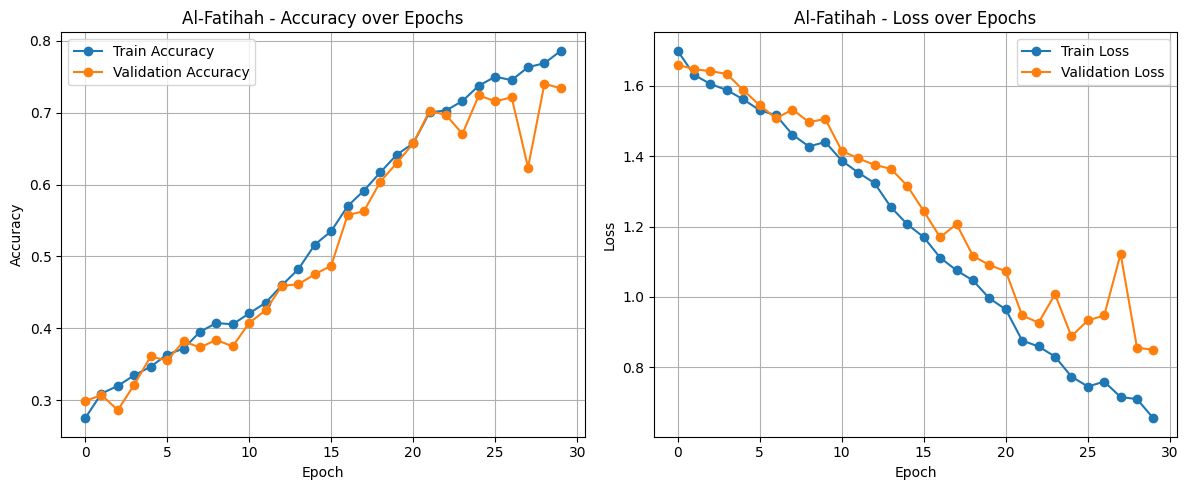

In [9]:
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load data
X = np.load("X_fatihah_mel.npy")
y = np.load("y_fatihah_labels.npy")

# Normalize and encode
X = (X - np.mean(X)) / np.std(X)
y_categorical = to_categorical(y - 1)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Build LSTM model
model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(X.shape[1], X.shape[2])),
    Dropout(0.3),
    LSTM(32),
    Dense(32, activation='relu'),
    Dense(y_categorical.shape[1], activation='softmax')
])

model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=8,
    callbacks=[early_stop]
)

# Save model
model.save("lstm_fatihah_classifier.keras")
print("✅ Model saved as lstm_fatihah_classifier.keras")

# Plot performance
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Al-Fatihah - Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Al-Fatihah - Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [8]:
import os
import pyaudio
import numpy as np
import librosa
import threading
from tensorflow.keras.models import load_model

# Load model
model = load_model("lstm_fatihah_classifier.keras")

# Verse mapping
verse_texts = {
    1: "بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ",
    2: "الْـحَمْدُ لِلَّهِ رَبِّ الْعَالَمِينَ",
    3: "الرَّحْمَٰنِ الرَّحِيمِ",
    4: "مَالِكِ يَوْمِ الدِّينِ",
    5: "إِيَّاكَ نَعْبُدُ وَإِيَّاكَ نَسْتَعِينُ",
    6: "اهْدِنَا الصِّرَاطَ الْمُسْتَقِيمَ",
    7: "صِرَاطَ الَّذِينَ أَنْعَمْتَ عَلَيْهِمْ غَيْرِ الْمَغْضُوبِ عَلَيْهِمْ وَلَا الضَّالِّينَ"
}

# 🎛️ Audio settings
RATE = 16000
CHUNK_DURATION = 6
CHUNK_SIZE = RATE * CHUNK_DURATION
N_MELS = 60
MAX_LEN = 180
CONFIDENCE_THRESHOLD = 0.4

stop_flag = False
highlighted_verses = set()
best_prediction = None
best_confidence = 0.0

# 🧠 Predict verse
def predict_chunk(audio_data):
    y_trimmed, _ = librosa.effects.trim(audio_data, top_db=25)
    if len(y_trimmed) == 0:
        return None, 0.0

    mel_spec = librosa.feature.melspectrogram(y=y_trimmed, sr=RATE, n_mels=N_MELS)
    log_mel = librosa.power_to_db(mel_spec).T

    if log_mel.shape[0] < MAX_LEN:
        log_mel = np.pad(log_mel, ((0, MAX_LEN - log_mel.shape[0]), (0, 0)), mode='constant')
    else:
        log_mel = log_mel[:MAX_LEN, :]

    log_mel = (log_mel - np.mean(log_mel)) / np.std(log_mel)
    log_mel = np.expand_dims(log_mel, axis=0)

    prediction = model.predict(log_mel, verbose=0)
    predicted_class = np.argmax(prediction) + 1
    confidence = np.max(prediction)

    return predicted_class, confidence

# 🖥️ Display verses
def display_verses(highlight_id=None):
    os.system('cls' if os.name == 'nt' else 'clear')
    print("\n📖 Surah Al-Fatihah\n")
    for i in range(1, 8):
        verse = verse_texts[i]
        if i == highlight_id:
            print(f">>> 🟢 {verse} <<<")
        elif i in highlighted_verses:
            print(f"✅ {verse}")
        else:
            print(f"⬜ {verse}")
    print("\n🎧 Listening...")

# 🛑 Wait for stop
def wait_for_stop():
    global stop_flag
    input("🔘 Press Enter to stop recitation...\n")
    stop_flag = True

# 🎙️ Real-time stream
p = pyaudio.PyAudio()
stream = p.open(format=pyaudio.paInt16,
                channels=1,
                rate=RATE,
                input=True,
                frames_per_buffer=CHUNK_SIZE)

listener_thread = threading.Thread(target=wait_for_stop)
listener_thread.start()

print("🎙️ Real-Time Surah Al-Fatihah Recitation Detection Started...\n")
display_verses()

try:
    while not stop_flag:
        audio_data = stream.read(CHUNK_SIZE, exception_on_overflow=False)
        audio_np = np.frombuffer(audio_data, dtype=np.int16).astype(np.float32) / 32768.0

        predicted_class, confidence = predict_chunk(audio_np)

        if predicted_class and confidence > CONFIDENCE_THRESHOLD:
            if confidence > best_confidence:
                best_prediction = predicted_class
                best_confidence = confidence

            highlighted_verses.add(predicted_class)
            display_verses(highlight_id=predicted_class)

except Exception as e:
    print(f"\n❌ Error: {e}")

finally:
    stream.stop_stream()
    stream.close()
    p.terminate()

    print("\n🛑 Recitation ended by user.")
    if best_prediction:
        print(f"\n━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━")
        print(f"✅ Most Confident Verse: V{best_prediction} | Confidence: {best_confidence:.2f}")
        print(f"🕋 {verse_texts[best_prediction]}")
    else:
        print("⚠️ No confident verse detected.")


🎙️ Real-Time Surah Al-Fatihah Recitation Detection Started...


📖 Surah Al-Fatihah

⬜ بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ
⬜ الْـحَمْدُ لِلَّهِ رَبِّ الْعَالَمِينَ
⬜ الرَّحْمَٰنِ الرَّحِيمِ
⬜ مَالِكِ يَوْمِ الدِّينِ
⬜ إِيَّاكَ نَعْبُدُ وَإِيَّاكَ نَسْتَعِينُ
⬜ اهْدِنَا الصِّرَاطَ الْمُسْتَقِيمَ
⬜ صِرَاطَ الَّذِينَ أَنْعَمْتَ عَلَيْهِمْ غَيْرِ الْمَغْضُوبِ عَلَيْهِمْ وَلَا الضَّالِّينَ

🎧 Listening...

📖 Surah Al-Fatihah

⬜ بِسْمِ اللَّهِ الرَّحْمَٰنِ الرَّحِيمِ
⬜ الْـحَمْدُ لِلَّهِ رَبِّ الْعَالَمِينَ
⬜ الرَّحْمَٰنِ الرَّحِيمِ
>>> 🟢 مَالِكِ يَوْمِ الدِّينِ <<<
⬜ إِيَّاكَ نَعْبُدُ وَإِيَّاكَ نَسْتَعِينُ
⬜ اهْدِنَا الصِّرَاطَ الْمُسْتَقِيمَ
⬜ صِرَاطَ الَّذِينَ أَنْعَمْتَ عَلَيْهِمْ غَيْرِ الْمَغْضُوبِ عَلَيْهِمْ وَلَا الضَّالِّينَ

🎧 Listening...

🛑 Recitation ended by user.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
✅ Most Confident Verse: V4 | Confidence: 0.57
🕋 مَالِكِ يَوْمِ الدِّينِ
